# Iris — KNN baseline

Part of my daily ML practice: one dataset, one question, one notebook.

The hello-world of classification. KNN with k=5, quick look at where it confuses versicolor and virginica.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_iris


## Data

In [ ]:
SEED = 1233
X, y = load_iris(return_X_y=True, as_frame=True)
df = X.copy(); df["species"] = y
print("shape:", df.shape)
print(df.groupby("species").size().to_string())
print(df.describe().round(2).to_string())


shape: (150, 5)
species
0    50
1    50
2    50
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species
count             150.00            150.00             150.00            150.00   150.00
mean                5.84              3.06               3.76              1.20     1.00
std                 0.83              0.44               1.77              0.76     0.82
min                 4.30              2.00               1.00              0.10     0.00
25%                 5.10              2.80               1.60              0.30     0.00
50%                 5.80              3.00               4.35              1.30     1.00
75%                 6.40              3.30               5.10              1.80     2.00
max                 7.90              4.40               6.90              2.50     2.00


## Petal scatter

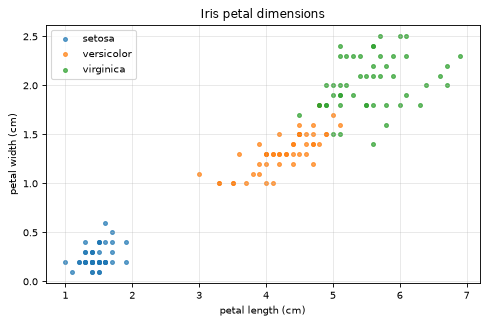

In [ ]:

fig, ax = plt.subplots()
for i, name in enumerate(["setosa", "versicolor", "virginica"]):
    d = df[df["species"] == i]
    ax.scatter(d["petal length (cm)"], d["petal width (cm)"], label=name, s=12, alpha=0.7)
ax.set_xlabel("petal length (cm)"); ax.set_ylabel("petal width (cm)")
ax.legend(); ax.set_title("Iris petal dimensions")


## Model

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)
knn = Pipeline([("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred,
      target_names=["setosa", "versicolor", "virginica"], digits=3))


accuracy: 0.9333
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.833     1.000     0.909        15
   virginica      1.000     0.800     0.889        15

    accuracy                          0.933        45
   macro avg      0.944     0.933     0.933        45
weighted avg      0.944     0.933     0.933        45



## Confusion matrix

plotted confusion matrix


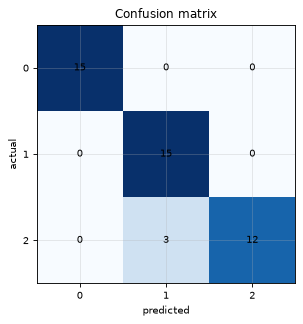

In [ ]:

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
k = cm.shape[0]
ax.set_xticks(range(k)); ax.set_yticks(range(k))
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
for i in range(k):
    for j in range(k):
        ax.text(j, i, cm[i, j], ha="center", va="center")
print("plotted confusion matrix")


## Takeaways

- Setosa separates perfectly; the errors are all versicolor/virginica.
- Petal features do all the work — sepal adds little.